# About:

Script used to validate trained CAM policy:
    
    + Plot action distribution 
    + Extract shapley values
    



In [1]:

# Standard Library Imports
import os
import sys
import pickle
import shutil

# Third Party Library Imports
import numpy as np
import torch
import pandas as pd
import torch as T
import shap
import matplotlib.pyplot as plt
import dill
from IPython.display import display, Javascript


# Local Imports 
from leo_gym.gyms.cam_gym import CamEnv, CamEnvConfig
from leo_gym.orbit.dynamics.dynamics import DynamicsConfig
from leo_gym.satellite.sat_debris_cluster import SatDebrisClusterConfig
from leo_gym.utils.utils import seed_all, create_dir
from leo_gym.rl_algorithms.h_ppo.h_ppo_agent import Agent
from leo_gym.rl_algorithms.h_ppo.config import PPOConfig



In [2]:
# Network Path

from pathlib import Path

path = "/home/nektaf/mlruns/707215638001269727/075f388e9ca24d6188919ebbc6bb3bb1"
timestep_save = "final"

experiment_path = Path(path)


In [3]:
# Dataset Path 

mc_csv_path = "/home/nektaf/mlruns/707215638001269727/075f388e9ca24d6188919ebbc6bb3bb1/artifacts/models/final/monte_carlo_cam_Ubuntu-22_2026-02-04_07-33-05/background_data_states.csv"


In [4]:
# Save SHAP plots path 

image_save_path = experiment_path / "artifacts/models" / timestep_save/ "shap"
os.makedirs(image_save_path, exist_ok=True)
os.chdir(image_save_path)


In [5]:
import json, numpy as np, re


env_cfg = experiment_path / "artifacts/env_cfg.json"


def make_env():
    seed = np.random.randint(0, 2**32)
    return CamEnv(env_cfg, seed)

num_envs = 1
env = make_env()
obs = env.reset()


In [6]:
# Load Agent 
device = 'cuda:3'


from leo_gym.rl_algorithms.h_ppo.h_ppo_agent import Agent

policy_file_path = experiment_path / "artifacts/models" / timestep_save / "policynet.pth"
critic_file_path = experiment_path / "artifacts/models" / timestep_save / "valuenet.pth"
ppo_config = experiment_path / "artifacts/ppo_cfg.json"

ppo = Agent(
    env_obs=env.observation_space,
    env_actions=env.action_space,
    ppo_cfg=ppo_config,
    train=False,
    policy_file_path=policy_file_path,
    critic_file_path=critic_file_path,
    device=device
)
model = ppo.policy_net


In [7]:

background_data = np.loadtxt(mc_csv_path, delimiter=",")
print(background_data)


[[ 4.23612387  1.12219714  2.24016079 ... -5.69660425 -0.1436836
   0.37987789]
 [ 3.01065316  1.12219714  2.24016079 ... -7.55038222 -0.5384046
   0.75140042]
 [ 1.9001288   1.12219714  2.24016079 ... -8.2925775  -0.88710972
   0.8855768 ]
 ...
 [ 1.98765055  2.04015834  3.20101601 ...  0.          0.
   0.        ]
 [ 6.24083789  2.04015834  3.20101601 ...  0.          0.
   0.        ]
 [ 1.39454672  2.04015834  3.20101601 ...  0.          0.
   0.        ]]


In [28]:
feature_names = [r"$u_{\text{p}}$", r"$i_{\text{p}}$",  r"$\Omega_{\text{p}}$", "$a\delta\lambda$", "$a\delta e_x$", "$a\delta e_y$", r"$u_{\text{s}}$", r"$i_{\text{s}}$", r"$\Omega_{\text{s}}$", r"$\Delta t_{\text{TCA}}$","$\det\mathbf{C}$", "$l$", r"$P^{\text{max}}_{\text{c}}$ ", r"$\delta r_\xi$", r"$\delta r_\zeta$"]
# feature_names = [r"$u_{\text{p}}$", "$a\delta\lambda$", "$a\delta e_x$", "$a\delta e_y$",r"$\Delta t_{\text{TCA}}$", r"$P^{\text{max}}_{\text{c}}$ "]


output_names = [ "0", "$+f_r$","$-f_r$", r"$\Delta t_\text{del}$", r"$\Delta t_{\text{dur}}$"]
len(feature_names)

15

In [29]:
from torch import nn
import torch 

class SHAPWrapper(nn.Module):
    def __init__(self, policy_net, min_val, max_val):
        super().__init__()
        self.policy_net = policy_net
        self.register_buffer("min_val", torch.tensor(min_val, dtype=torch.float32))
        self.register_buffer("max_val", torch.tensor(max_val, dtype=torch.float32))

    def forward(self, states):
        dist_dis, dist_cont = self.policy_net(states)
        probs = (dist_dis.probs * 100.0).view(states.size(0), -1)
        cont = dist_cont.mean
        act_scale = (self.max_val - self.min_val) / 2.0
        act_bias = (self.max_val + self.min_val) / 2.0
        cont = (cont.clamp(-1, 1) * act_scale + act_bias).view(states.size(0), -1)
        return torch.cat([probs, cont], dim=1)


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
min_val = [9, 1]
max_val = [55, 41]

policy_net = model
policy_net.eval()

wrapper = SHAPWrapper(policy_net, min_val, max_val).eval().to(device)


In [30]:
import numpy as np
import torch
import shap

K = 100
n_test = 1000

background_subset = np.asarray(shap.sample(background_data, K), dtype=np.float32)
idx = np.random.choice(background_data.shape[0], n_test, replace=False)
x_test_np = np.asarray(background_data[idx], dtype=np.float32)

x_bg = torch.tensor(background_subset, dtype=torch.float32, device=device)
x_test = torch.tensor(x_test_np, dtype=torch.float32, device=device)

wrapper = wrapper.eval().to(device)

explainer = shap.DeepExplainer(wrapper, x_bg)
shap_values = explainer.shap_values(x_test, check_additivity=False)

shap_exp = shap.Explanation(
    values=shap_values,
    data=x_test.detach().cpu().numpy(),
    feature_names=feature_names
)


In [31]:
background_data.shape

(7310, 15)

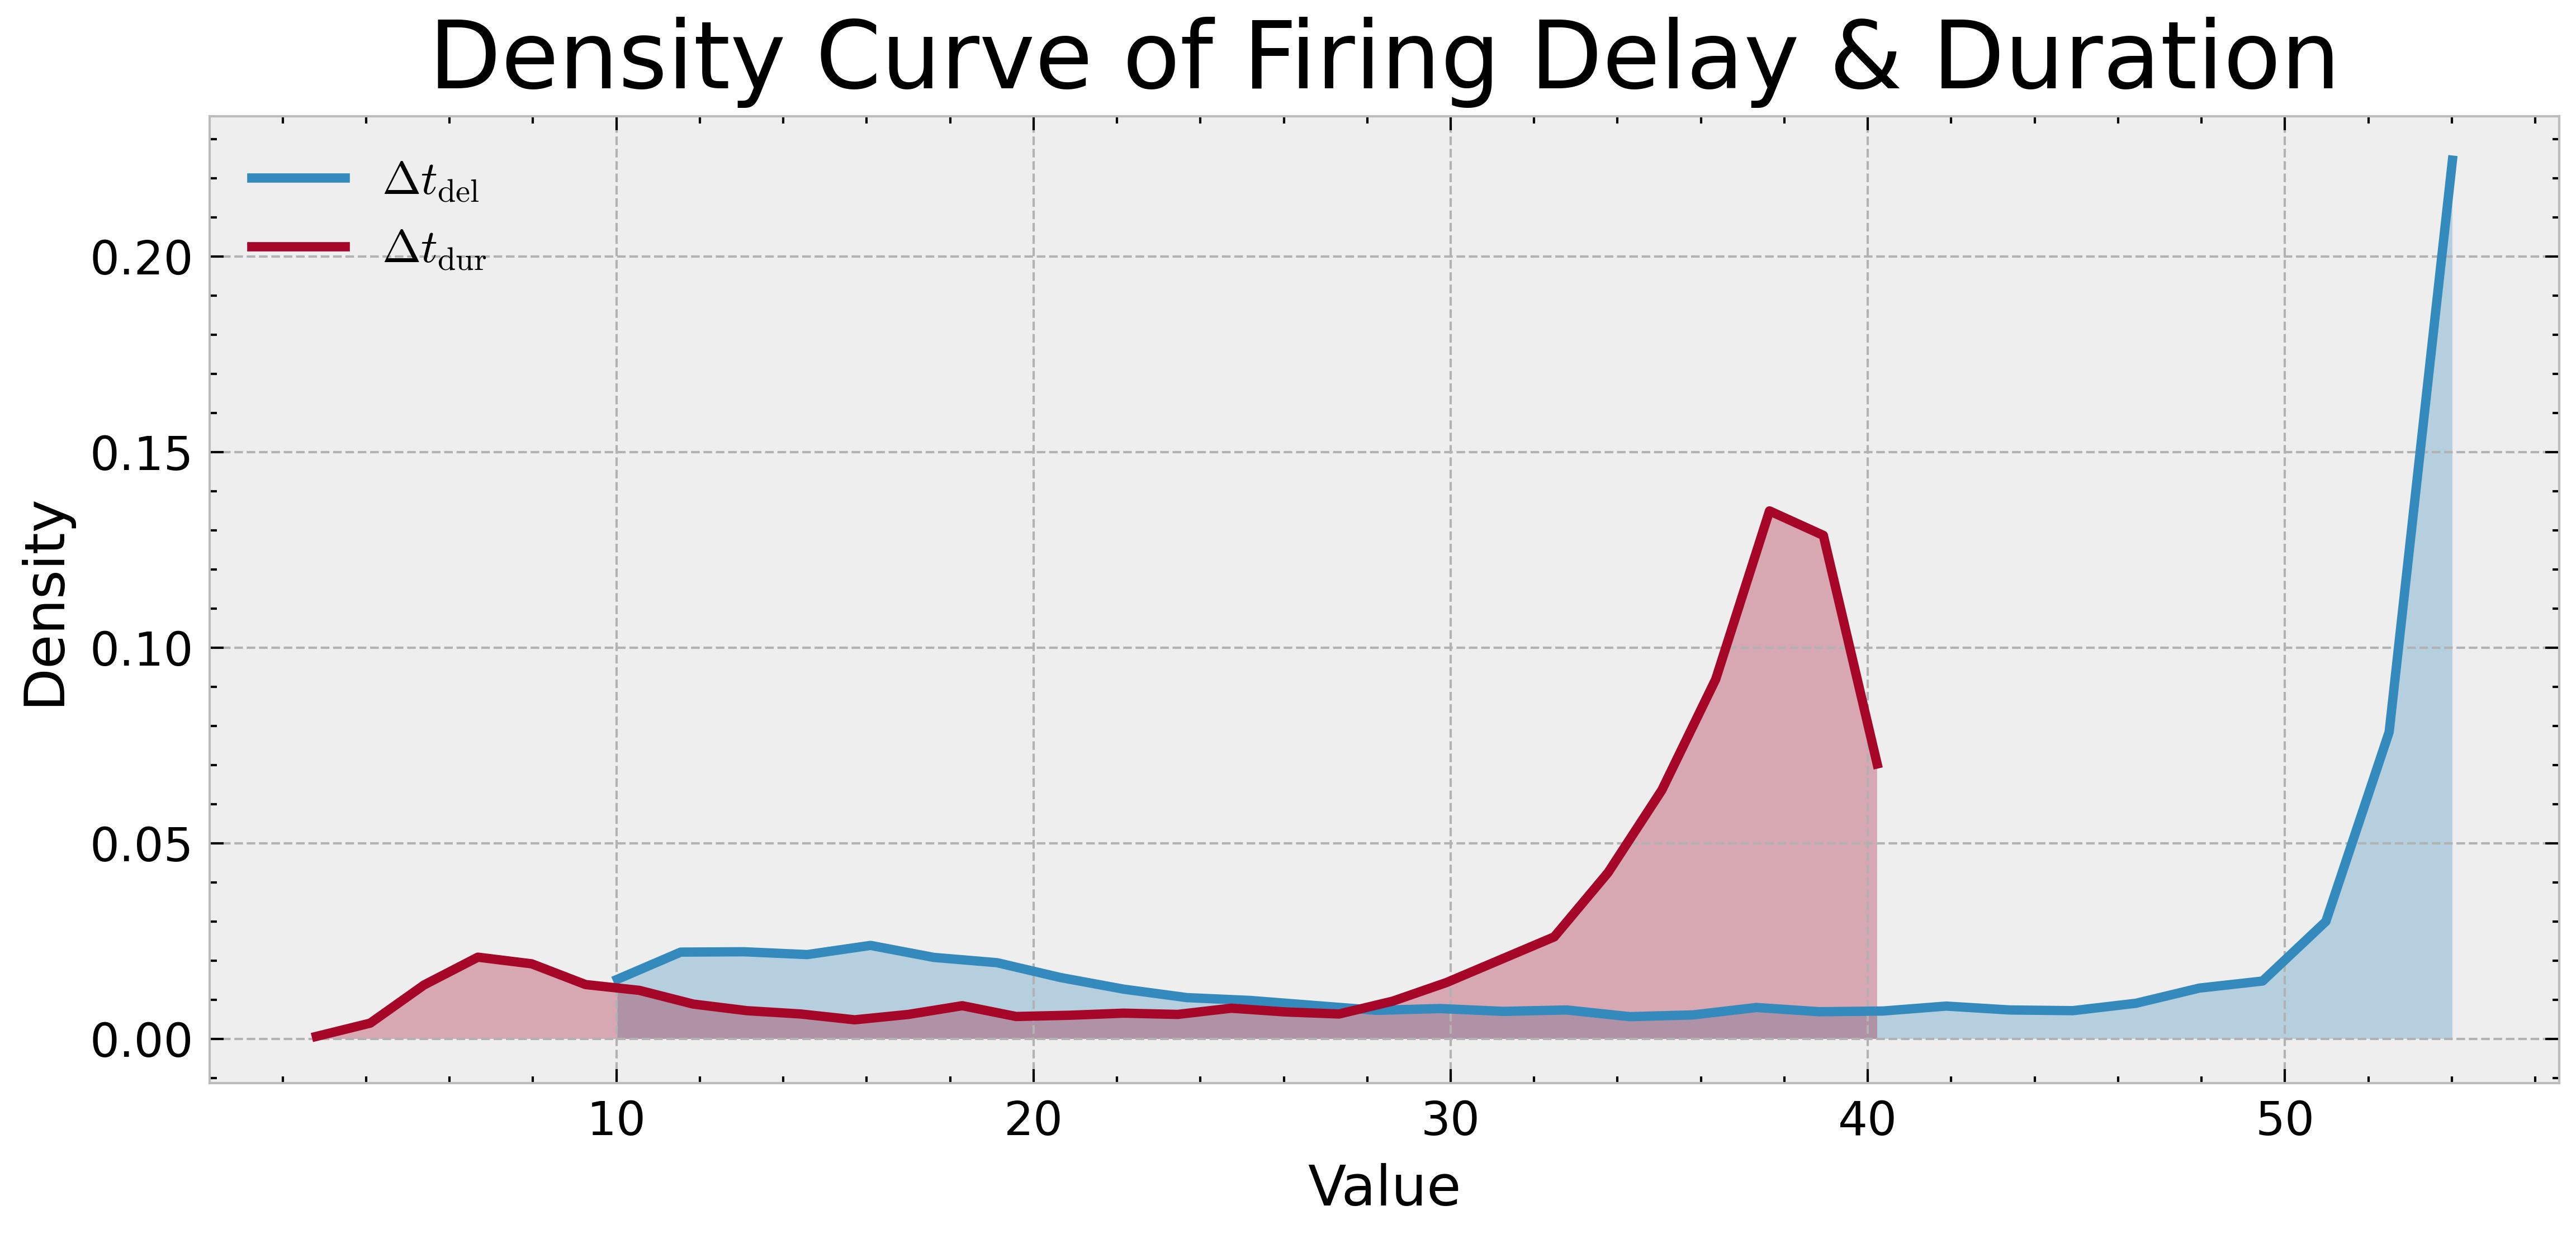

In [32]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pickle

bg_tensor = torch.tensor(background_data, dtype=torch.float32)

with torch.no_grad():
    outputs = wrapper(bg_tensor)

outputs = outputs.detach().cpu().numpy().reshape(outputs.shape[0], -1)
outputs
cont = outputs[:, 3:]  

plt.figure(figsize=(8, 4))
bins = 30

for i in range(cont.shape[1]):
    counts, edges = np.histogram(cont[:, i], bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    plt.plot(centers, counts, label=output_names[i+3])
    plt.fill_between(centers, counts, alpha=0.3)

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Density Curve of Firing Delay & Duration')
plt.legend()
plt.tight_layout()
plt.savefig("cont_act_distr.png",dpi=300) 


In [33]:
outputs

array([[4.7363527e-02, 9.9952637e+01, 8.6022283e-08, 5.3952553e+01,
        3.5920036e+01],
       [2.7288991e-01, 9.9727112e+01, 1.1886108e-06, 5.3451790e+01,
        3.7497295e+01],
       [2.1861763e-01, 9.9781380e+01, 1.6323577e-06, 5.1584747e+01,
        3.8723251e+01],
       ...,
       [1.6995154e-01, 4.3192902e-01, 9.9398117e+01, 5.1988441e+01,
        2.3411139e+01],
       [1.6466299e-02, 6.0221534e-03, 9.9977509e+01, 1.4709087e+01,
        1.1887523e+01],
       [3.4508541e-01, 3.4401619e+01, 6.5253296e+01, 4.8732681e+01,
        3.6109581e+00]], dtype=float32)

In [34]:


shap_values_all = shap.Explanation(values=shap_values, 
                                    data=x_test_np,
                                    feature_names=feature_names,
                                    output_names=output_names)


In [35]:
shap_values_all.shape

(1000, 15, 5)

In [ ]:

save_file_name = ["shap_f_0_summary_plot.png","shap_f_summary_plot.png","shap_f_neg_summary_plot.png","shap_dt0_summary_plot.png","shap_dtman_summary_plot.png"]
save_file_name2 = ["shap_f_0_beeswarm_plot.png","shap_f_beeswarm_plot.png","shap_f_neg_beeswarm_plot.png","shap_dt0_beeswarm_plot.png","shap_dtman_beeswarm_plot.png"]
save_file_name3 = ["shap_f_0_bar_plot.png","shap_f_bar_plot.png","shap_f_neg_bar_plot.png","shap_dt0_bar_plot.png","shap_dtman_bar_plot.png"]

for i in range(len(save_file_name)):
    print(output_names[i])
    
    # ax = shap.plots.scatter(shap_values_all[:,:,output_names[i]], show=False)
    # plt.savefig(save_file_name[i],dpi=300) 
    # plt.close(fig)
    
    shap.plots.beeswarm(shap_values_all[:,:,output_names[i]], show=False)
    fig, ax = plt.gcf(), plt.gca()
    ax.tick_params(labelsize=20)
    
    # Get colorbar
    cb_ax = fig.axes[1] 

    # Modifying color bar parameters
    cb_ax.tick_params(labelsize=15)
    cb_ax.set_ylabel("Feature value", fontsize=20)

    plt.savefig(save_file_name2[i],dpi=600, bbox_inches="tight") 
    plt.close(fig)

    # ax = shap.plots.bar(shap_values_all[:,:,output_names[i]], show=False)
    # fig = plt.gcf()
    # plt.savefig(save_file_name3[i],dpi=300) 
    # plt.close(fig)
    
    

0
$+f_r$
$-f_r$
$\Delta t_\text{del}$
$\Delta t_{\text{dur}}$
